# Setup

In [1]:
from manim import *
import numpy as np
config.media_width = "75%"
config.verbosity = "WARNING"

# colors

gradient_colors = [r"#43cea2", r"#185a9d"]

In [ ]:
%%manim -qh Thumbnail

class Thumbnail(Scene):
    def construct(self):
        title = Tex("Title", font_size=165)
        #title.set_color_by_gradient(*gradient_colors)
        self.add(title)

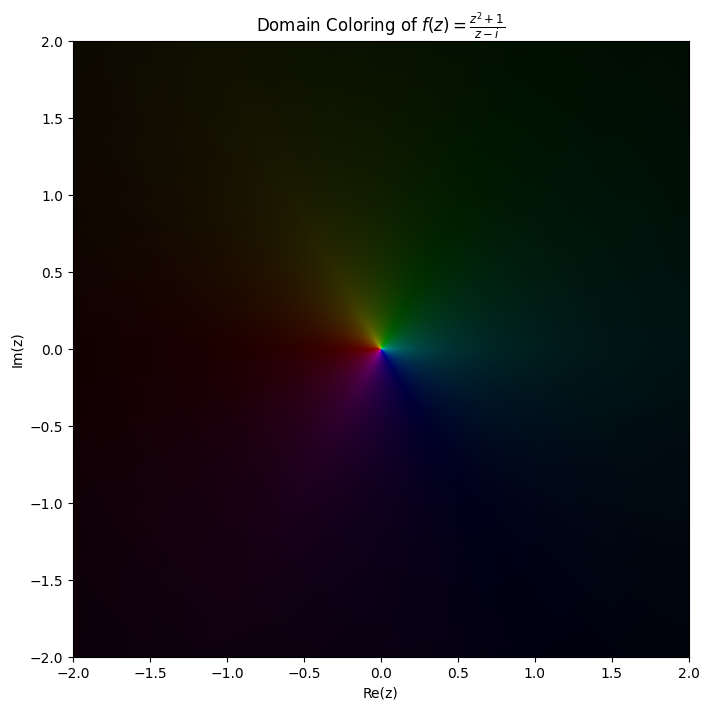

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb

# Define the complex function
def complex_function(z):
    return 1/z

# Create a grid of complex numbers
x = np.linspace(-2, 2, 1000)
y = np.linspace(-2, 2, 1000)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
W = complex_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized  # Value/Brightness

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring
plt.figure(figsize=(8, 8))
plt.imshow(rgb, extent=(-2, 2, -2, 2), origin='lower')
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.title('Domain Coloring of $f(z) = \\frac{z^2 + 1}{z - i}$')
plt.show()


### Holomorphic function on unit disk with infinite number of zeros

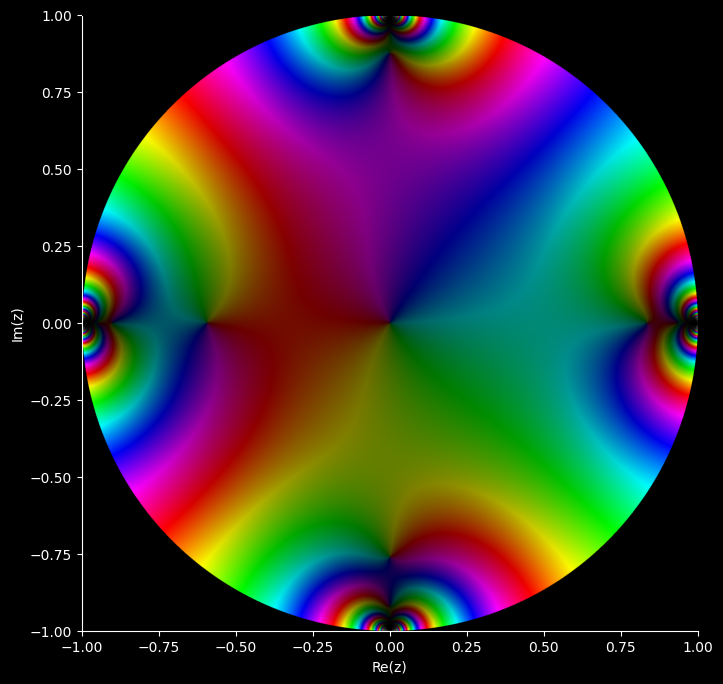

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)**2/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function2(z):
    zeros = [(1- 1/i**(1.3)) * cmath.exp(1j*np.pi* i/2) for i in range(1,200)]
    
    #zeros = [0]
    res = 1 #cmath.exp(z)
    for i in zeros:
        res *= blaschke_factor(i)(z)
        """if i == 0:
            res *= z
        else:
            res *= (1-z/i) #1- z/ i"""
    return res  # Replace with any function having poles



# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-1, 1, res)
y = np.linspace(-1, 1, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# Mask points outside the unit disk
mask = np.abs(Z) <= 1
Z = np.where(mask, Z, 0)  # Keep points inside the disk, set others to 0

# Apply the function
#meromorphic_function = np.vectorize(meromorphic_function2)
W = meromorphic_function2(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.2)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-1, 1, -1, 1), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()


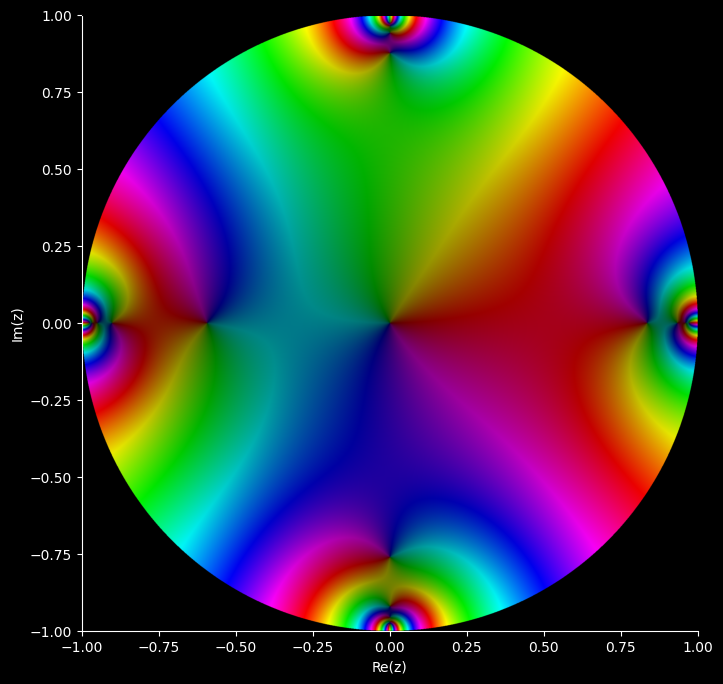

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function2(z):
    zeros = [(1- 1/i**(1.3)) * cmath.exp(1j*np.pi* i/2) for i in range(1,20)]
    
    #zeros = [0]
    res = z**2 - 2 #cmath.exp(z)
    for i in zeros:
        res *= blaschke_factor(i)(z)
        """if i == 0:
            res *= z
        else:
            res *= (1-z/i) #1- z/ i"""
    return res  # Replace with any function having poles



# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-1, 1, res)
y = np.linspace(-1, 1, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# Mask points outside the unit disk
mask = np.abs(Z) <= 1
Z = np.where(mask, Z, 0)  # Keep points inside the disk, set others to 0

# Apply the function
#meromorphic_function = np.vectorize(meromorphic_function2)
W = meromorphic_function2(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.2)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-1, 1, -1, 1), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()


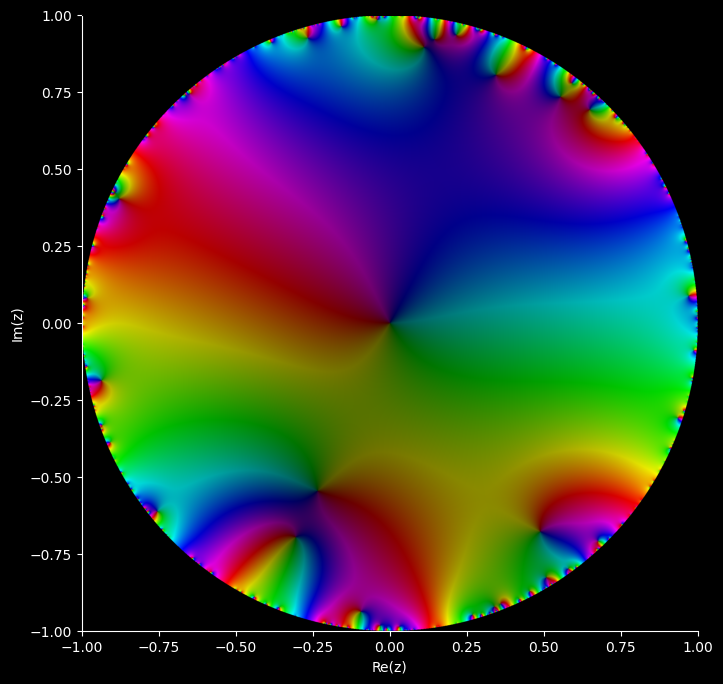

'plt.figure(figsize=(8, 8), facecolor=\'black\')\nplt.imshow(rgb, extent=(-1, 1, -1, 1), origin=\'lower\')\nplt.xlabel(\'Re(z)\')\nplt.ylabel(\'Im(z)\')\nplt.gca().set_aspect(\'equal\', adjustable=\'box\')  # Keep aspect ratio equal\nplt.gcf().set_facecolor("white")\nplt.show()'

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_functionran(z):
    zeros = [(1- 1/i**(1.3)) * cmath.exp(1j*random.uniform(0,1)*2*np.pi) for i in range(1,300)]
    
    #zeros = [0]
    res = 1
    for i in zeros:
        res *= blaschke_factor(i)(z)
        """if i == 0:
            res *= z
        else:
            res *= (1-z/i) #1- z/ i"""
    return res  # Replace with any function having poles



# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-1, 1, res)
y = np.linspace(-1, 1, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# Mask points outside the unit disk
mask = np.abs(Z) <= 1
Z = np.where(mask, Z, 0)  # Keep points inside the disk, set others to 0

# Apply the function
W = meromorphic_functionran(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.2)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-1, 1, -1, 1), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()

"""plt.figure(figsize=(8, 8), facecolor='black')
plt.imshow(rgb, extent=(-1, 1, -1, 1), origin='lower')
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.gca().set_aspect('equal', adjustable='box')  # Keep aspect ratio equal
plt.gcf().set_facecolor("white")
plt.show()"""


### Meromorphic function on unit disk with infinite number of poles

C:\Users\robin\AppData\Local\Temp\ipykernel_18712\2652501559.py:20: RuntimeWarning: divide by zero encountered in divide
  res *= 1/(z-i)
C:\Users\robin\AppData\Local\Temp\ipykernel_18712\2652501559.py:20: RuntimeWarning: invalid value encountered in divide
  res *= 1/(z-i)
C:\Users\robin\AppData\Local\Temp\ipykernel_18712\2652501559.py:20: RuntimeWarning: invalid value encountered in multiply
  res *= 1/(z-i)


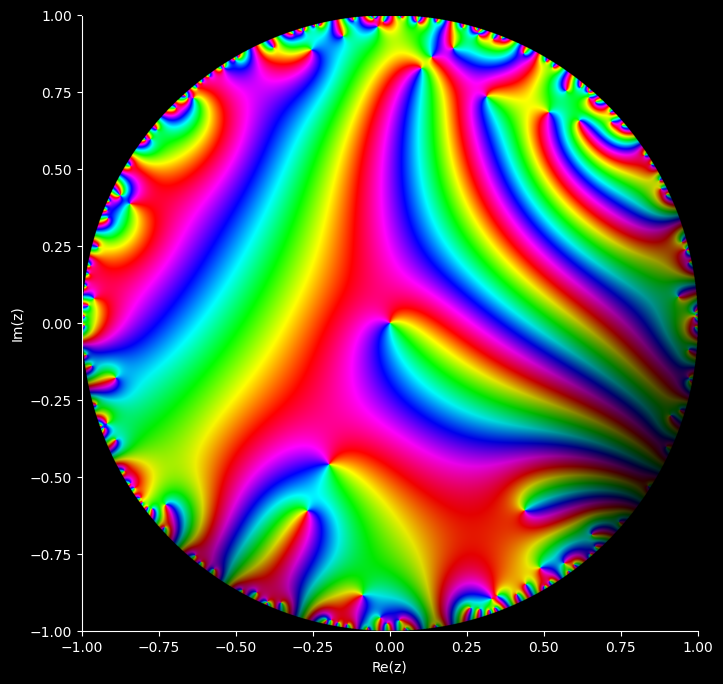

'plt.figure(figsize=(8, 8), facecolor=\'black\')\nplt.imshow(rgb, extent=(-1, 1, -1, 1), origin=\'lower\')\nplt.xlabel(\'Re(z)\')\nplt.ylabel(\'Im(z)\')\nplt.gca().set_aspect(\'equal\', adjustable=\'box\')  # Keep aspect ratio equal\nplt.gcf().set_facecolor("white")\nplt.show()'

In [201]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function2(z):
    zeros = [(1- 1/i) * cmath.exp(1j*random.uniform(0,1)*2*np.pi) for i in range(1,150)]
    
    #zeros = [0]
    res = 1
    for i in zeros:
        res *= 1/(z-i)
        """if i == 0:
            res *= z
        else:
            res *= (1-z/i) #1- z/ i"""
    return res  # Replace with any function having poles



# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-1, 1, res)
y = np.linspace(-1, 1, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# Mask points outside the unit disk
mask = np.abs(Z) <= 1
Z = np.where(mask, Z, 0)  # Keep points inside the disk, set others to 0

# Apply the function
meromorphic_function = np.vectorize(meromorphic_function2)
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_clamped = np.clip(magnitude, 0, 1e2)  # Clamp magnitude to avoid infinity
magnitude_normalized = np.log1p(magnitude_clamped) / np.log1p(1e2)
#magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.1)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-1, 1, -1, 1), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()

"""plt.figure(figsize=(8, 8), facecolor='black')
plt.imshow(rgb, extent=(-1, 1, -1, 1), origin='lower')
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.gca().set_aspect('equal', adjustable='box')  # Keep aspect ratio equal
plt.gcf().set_facecolor("white")
plt.show()"""


### Polynomials

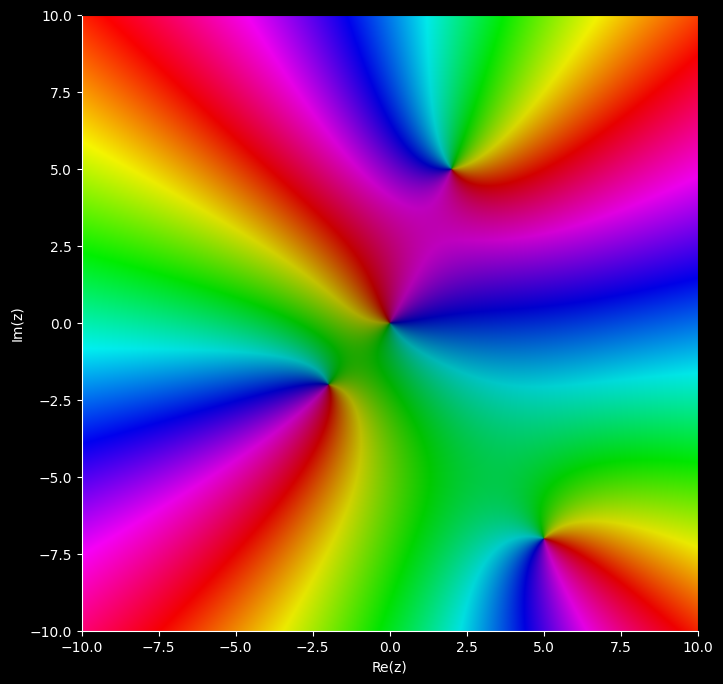

In [222]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function(z):
    return z* (z - (5j +2)) * (z - (-2j - 2)) * (z - (-7j + 5))
    #return 10*z**4 + 5*z**3 - 2*z**2 + 5j*z -0
    #return 5*(z-1)* (z - 3j + 2) * (z + 4j -1)



# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-10, 10, res)
y = np.linspace(-10, 10, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y


# Apply the function
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.5)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-10, 10, -10, 10), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()


### Rational function

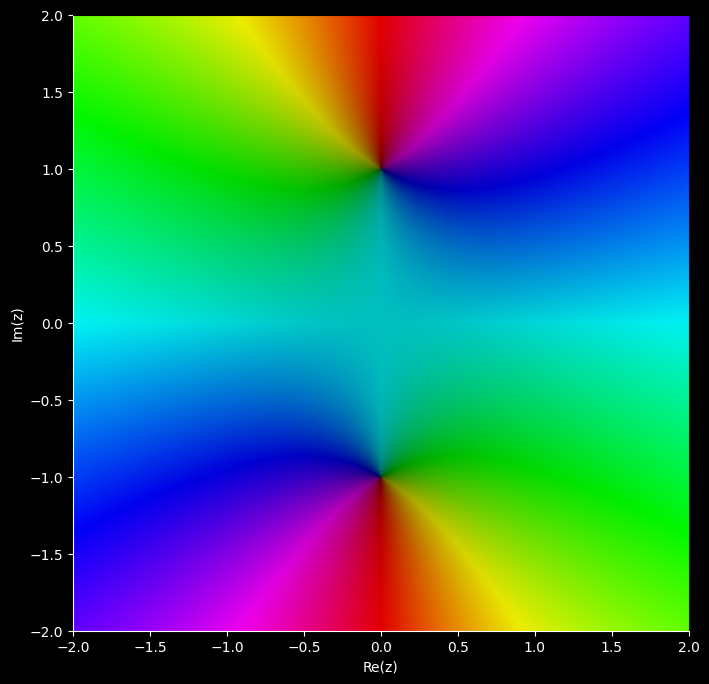

In [228]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function(z):
    return (z**2 + 1)



# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-2, 2, res)
y = np.linspace(-2, 2, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y


# Apply the function
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.25)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-2, 2, -2, 2), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()


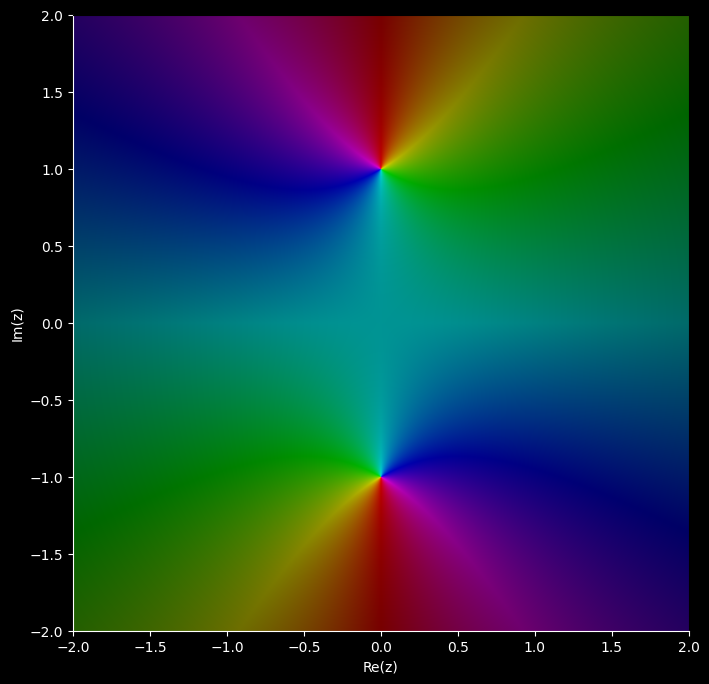

In [227]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function(z):
    return 1/(z**2 + 1)



# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-2, 2, res)
y = np.linspace(-2, 2, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y


# Apply the function
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.25)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-2, 2, -2, 2), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()


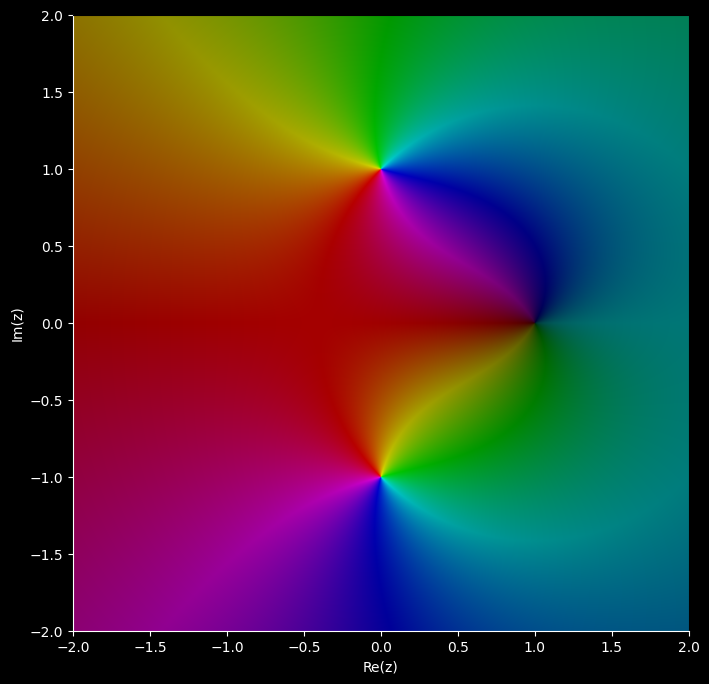

In [282]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function(z):
    return (2*z - 2)/(z**2 + 1)


# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-2, 2, res)
y = np.linspace(-2, 2, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y


# Apply the function
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.25)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-2, 2, -2, 2), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()


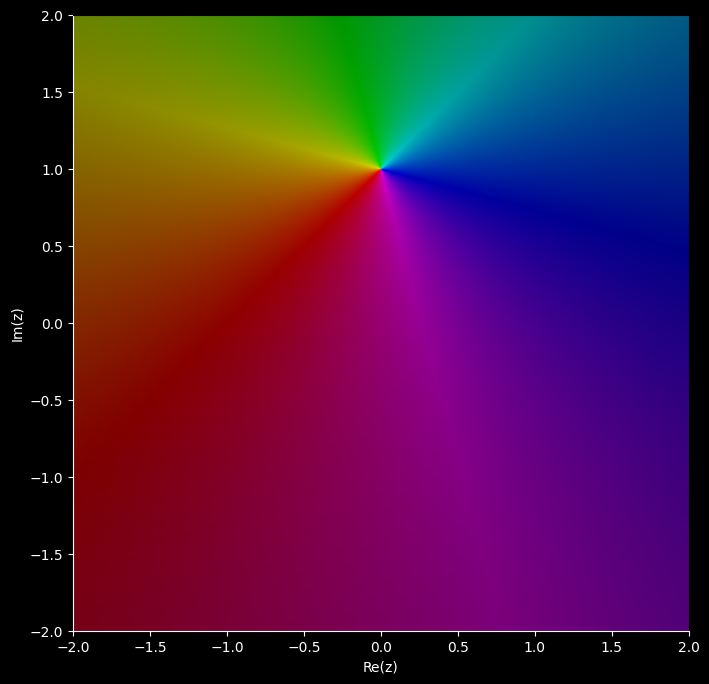

In [238]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function(z):
    return (1+1j)/(z-1j)


# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-2, 2, res)
y = np.linspace(-2, 2, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y


# Apply the function
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.25)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-2, 2, -2, 2), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()


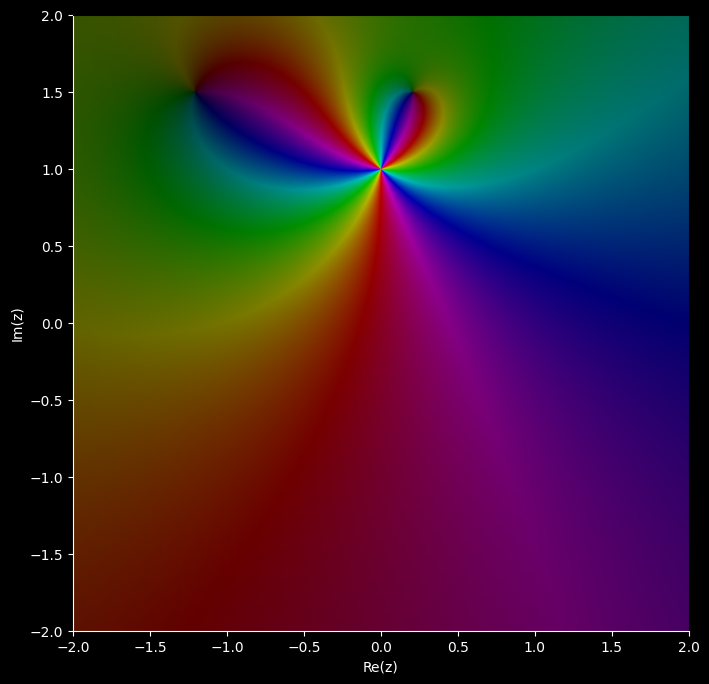

In [248]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function(z):
    return (1+1j)/(z-1j) + (2)/(z-1j)**2 - (1j)/(z-1j)**3


# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-2, 2, res)
y = np.linspace(-2, 2, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y


# Apply the function
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.25)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-2, 2, -2, 2), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()


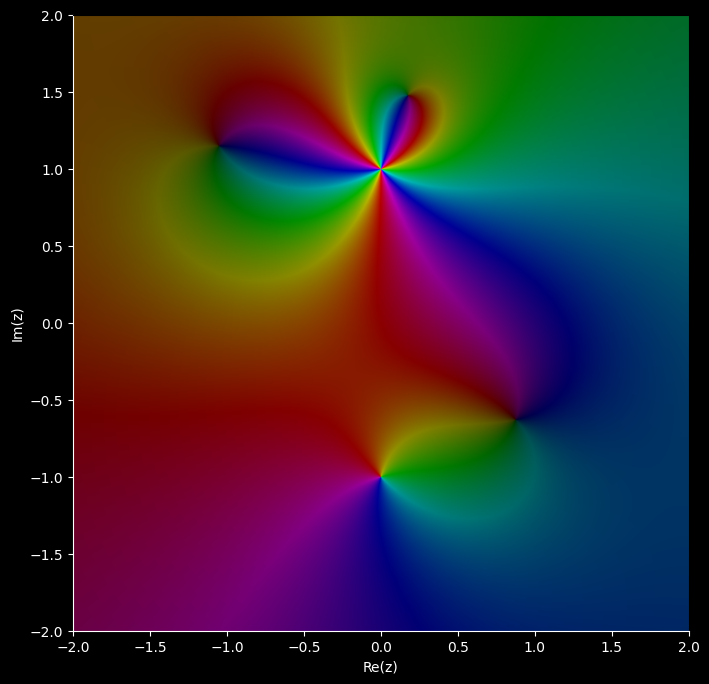

In [249]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function(z):
    return (1+1j)/(z-1j) + (2)/(z-1j)**2 - (1j)/(z-1j)**3 + (1-1j)/(z+1j)


# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-2, 2, res)
y = np.linspace(-2, 2, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y


# Apply the function
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.25)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-2, 2, -2, 2), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()


## examples

sin(pi * z)

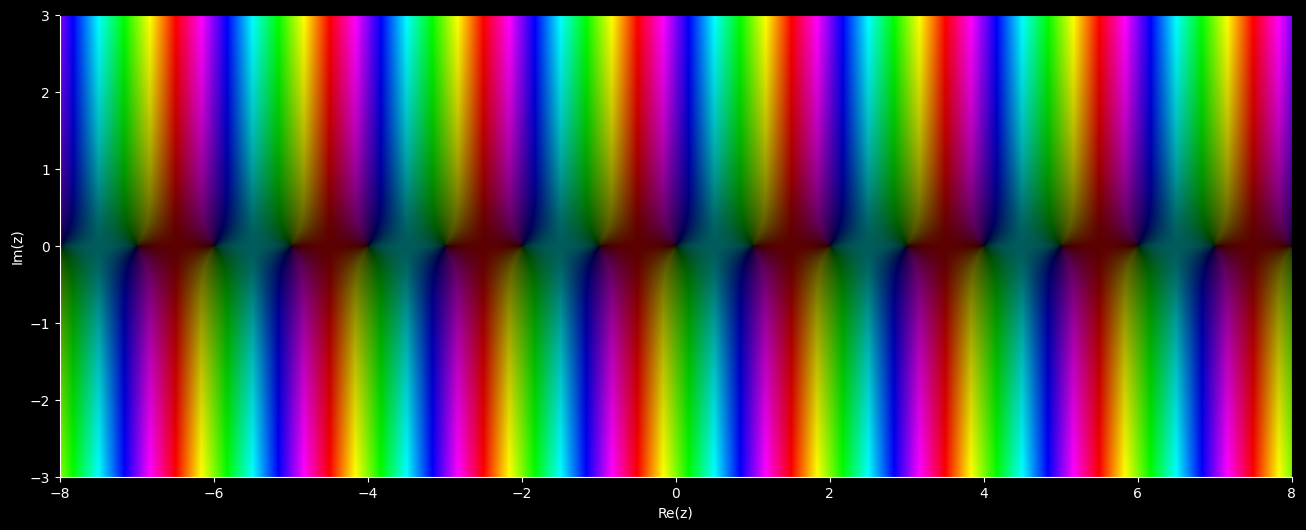

In [261]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function2(z):
    return cmath.sin(np.pi * z)


# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-8, 8, res)
y = np.linspace(-3, 3, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y


# Apply the function
meromorphic_function = np.vectorize(meromorphic_function2)
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.4)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(16, 6))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-8, 8, -3, 3), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()


1/gamma(z)

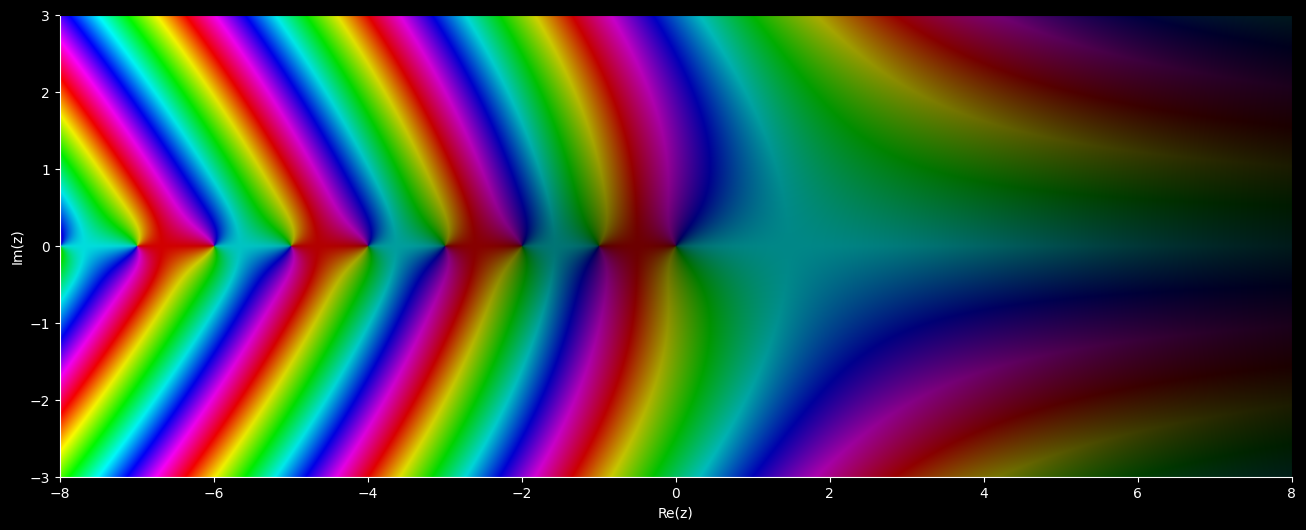

'fig, ax = plt.subplots(figsize=(16, 4.5))\n\nax.set_facecolor(\'white\')\nax.imshow(rgb, extent=(-8, 8, -2.25, 2.25), origin=\'lower\')\nax.set_aspect(\'equal\', adjustable=\'box\')  # Keep aspect ratio equal\n\n# Remove coordinate system\nax.axis(\'off\')\n\n#fig.patch.set_facecolor("black")\n\nplt.show()'

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
from scipy.special import gamma
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function(z):
    return 1/gamma(z)


# Create a grid of complex numbers within the unit disk
res = 4000  # Resolution of the grid
x = np.linspace(-8, 8, res)
y = np.linspace(-3, 3, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y


# Apply the function
#meromorphic_function = np.vectorize(meromorphic_function2)
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.2)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(16, 6))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-8, 8, -3, 3), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()

"""fig, ax = plt.subplots(figsize=(16, 4.5))

ax.set_facecolor('white')
ax.imshow(rgb, extent=(-8, 8, -2.25, 2.25), origin='lower')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

# Remove coordinate system
ax.axis('off')

#fig.patch.set_facecolor("black")

plt.show()"""


(pi / sin(pi * z))^2

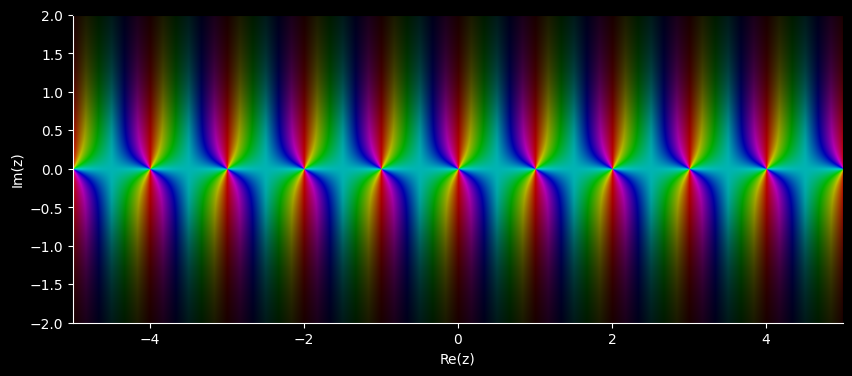

In [279]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function2(z):
    return (np.pi/cmath.sin(np.pi * z))**2


# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-5, 5, res)
y = np.linspace(-2, 2, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y


# Apply the function
meromorphic_function = np.vectorize(meromorphic_function2)
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.2)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(10, 4))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-5, 5, -2, 2), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()


pi * cot(pi * z)

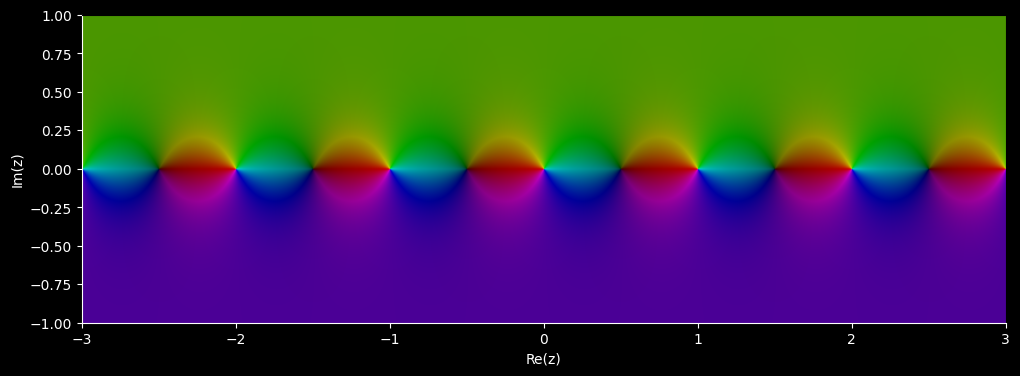

'fig, ax = plt.subplots(figsize=(12, 4))\n\nax.set_facecolor(\'white\')\nax.imshow(rgb, extent=(-3, 3, -1, 1), origin=\'lower\')\n#ax.set_aspect(\'equal\', adjustable=\'box\')  # Keep aspect ratio equal\n\n# Remove coordinate system\nax.axis(\'off\')\n\n#fig.patch.set_facecolor("black")\nplt.savefig(\'output.png\', bbox_inches=\'tight\', transparent=True)\nplt.show()'

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function2(z):
    return np.pi * cmath.cos(np.pi * z) / cmath.sin(np.pi * z)


# Create a grid of complex numbers within the unit disk
res = 4000  # Resolution of the grid
x = np.linspace(-3, 3, res)
y = np.linspace(-1, 1, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y


# Apply the function
meromorphic_function = np.vectorize(meromorphic_function2)
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.3)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(12, 4))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-3, 3, -1, 1), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()

"""fig, ax = plt.subplots(figsize=(12, 4))

ax.set_facecolor('white')
ax.imshow(rgb, extent=(-3, 3, -1, 1), origin='lower')
#ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

# Remove coordinate system
ax.axis('off')

#fig.patch.set_facecolor("black")
plt.savefig('output.png', bbox_inches='tight', transparent=True)
plt.show()"""


In [ ]:
(pi / sin(pi * z))

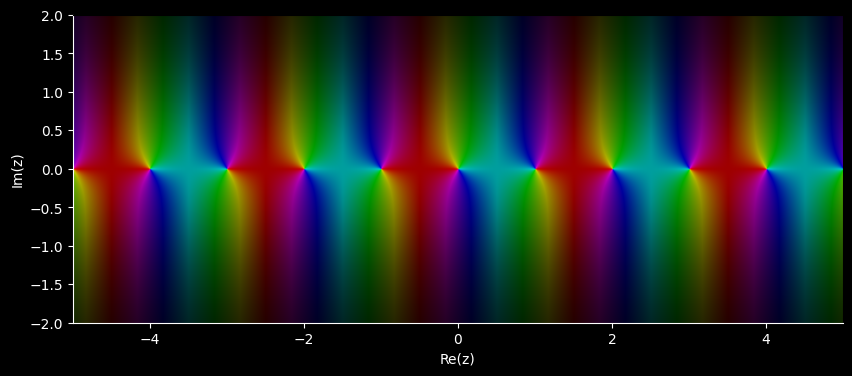

In [281]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import cmath
import random
random.seed(13)

# Define the holomorphic or meromorphic function
def blaschke_factor(a):
    if a == 0:
        return lambda z: z
    return lambda z : abs(a)/a * (a-z)/(1-np.conj(a)*z)

def meromorphic_function2(z):
    return (np.pi/cmath.sin(np.pi * z))


# Create a grid of complex numbers within the unit disk
res = 2000  # Resolution of the grid
x = np.linspace(-5, 5, res)
y = np.linspace(-2, 2, res)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y


# Apply the function
meromorphic_function = np.vectorize(meromorphic_function2)
W = meromorphic_function(Z)

# Calculate magnitude and phase
magnitude = np.abs(W)
phase = np.angle(W)

# Normalize magnitude and phase
magnitude_normalized = np.log1p(magnitude) / np.max(np.log1p(magnitude))
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Create HSV color map
hsv = np.zeros((*phase_normalized.shape, 3))
hsv[..., 0] = phase_normalized  # Hue
hsv[..., 1] = 1                 # Saturation
hsv[..., 2] = magnitude_normalized**(0.3)  # Brightness masked to the disk

# Convert HSV to RGB
rgb = hsv_to_rgb(hsv)

# Plot the domain coloring

fig, ax = plt.subplots(figsize=(10, 4))

ax.set_facecolor('white')

ax.imshow(rgb, extent=(-5, 5, -2, 2), origin='lower')
ax.set_xlabel('Re(z)', color='white')
ax.set_ylabel('Im(z)', color='white')
ax.set_aspect('equal', adjustable='box')  # Keep aspect ratio equal

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='both', colors='white')
fig.patch.set_facecolor("black")

plt.show()


# Title

In [23]:
%%manim -qh S1

class S1(Scene):
    def construct(self):
        poly = MathTex(r"p(z) = \sum_{k=0}^d p_k z^k")
        poly.move_to(UP*3)
        poly2 = MathTex(r"p(z) = c\prod_{k=0}^n (z - a_k)^{m(a_k)}")
        poly2.move_to(UP*3)

        axes = Axes(
            x_range=[-1, 1, 0.25],  # x-axis from -4 to 4 with step size 1
            y_range=[-1, 1, 0.25],  # y-axis from 0 to 16 with step size 2
            x_length=5,          # Length of the x-axis
            y_length=5,          # Length of the y-axis
            tips=False,          # Disable arrow tips
        )
        axes.move_to(DOWN)

        func = axes.plot(lambda x: x**3 + x**2 - x, color=BLUE)

        self.play(FadeIn(axes))
        self.play(Create(func), Write(poly))
        self.wait()
        self.play(Transform(poly, poly2))
        self.wait()
        self.play(FadeOut(func, axes))
        self.wait()
        self.play(FadeOut(poly))

Manim Community v0.18.1

In [36]:
%%manim -qh S2

class S2(Scene):
    def construct(self):
        rat = MathTex(r"r(z) = \frac{p(z)}{q(z)}")
        ex = MathTex(r"r(z) = \frac{2z-2}{z^2 + 1}")
        ex.move_to(UP*3)
        dec = MathTex(r"z^2 + 1 = (z-i)(z+i)")
        dec.move_to(UP*3)
        rec = MathTex(r"\frac{1}{(z-i)(z+i)}")
        rec.move_to(UP*3)
        ex2 = MathTex(r"\frac{2z-2}{(z-i)(z+i)}")
        ex2.move_to(UP*3)
        ex3 = MathTex(r"\frac{2z-2}{(z-i)(z+i)} =", r" \frac{1+i}{z-i} + \frac{1-i}{z+i}")
        ex3.move_to(UP*3)
        princ = MathTex(r"\text{principal part at } i: p_i(z) = \frac{1+i}{z-i}")
        princ.move_to(UP*3 + RIGHT*3)
        princ2 = MathTex(r"\text{principal part at } i")
        princ2.move_to(UP*3 + RIGHT*3)
        tex = Tex(r"rational function")
        tex.move_to(UP*3 + LEFT*4.3)

        self.play(Write(rat))
        self.wait()
        self.play(Write(ex))
        self.wait(3)
        self.play(FadeOut(rat, ex))
        self.play(FadeIn(dec))
        self.wait(3)
        self.play(ReplacementTransform(dec, rec))
        self.wait(3)
        self.play(ReplacementTransform(rec, ex2))
        self.wait(3)
        self.play(ReplacementTransform(ex2, ex3))
        self.wait(3)
        self.play(ex3[1].animate.shift(LEFT*6), FadeOut(ex3[0]))
        self.play(Write(princ))
        self.wait(3)
        self.play(Transform(princ, princ2), ReplacementTransform(ex3[1], tex))
        self.wait(3)
        self.play(FadeOut(princ, tex))
        
        

Manim Community v0.18.1

In [3]:
%%manim -qh S3

class S3(Scene):
    def construct(self):
        title = Tex(r"Partial fraction decomposition")
        title.set_color_by_gradient(*gradient_colors)
        rat = MathTex(r"r(z) = \frac{p(z)}{q(z)}")
        down = MathTex(r"q(z) = c\prod_{k=1}^n (z - a_k)^{n_k}")
        partial = MathTex(r"\frac{p(z)}{q(z)} = f(z) + \sum_{k=1}^n \sum_{l=1}^{n_k} \frac{c_{k,l}}{(z-a_k)^l}")
        princ = MathTex(r"\text{Principal parts: }", r"p_{a_k}(z) = \sum_{l=1}^{n_k} \frac{c_{k,l}}{(z-a_k)^l")
        princ[0].set_color(BLUE)
        func = MathTex(r"r:\mathbb{C} \to \hat{\mathbb{C}} \quad (\hat{\mathbb{C}} = \mathbb{C} \cup \{\infty\})")

        title.move_to(UP*3.3)
        rat.move_to(UP*2 + LEFT*3)
        down.move_to(UP*2 + RIGHT*3)
        partial.move_to(ORIGIN)
        princ.move_to(DOWN*2)
        func.move_to(DOWN*3.5)
        
        self.play(FadeIn(rat, down))
        self.wait()
        self.play(FadeIn(partial, title))
        self.wait()
        self.play(FadeIn(princ))
        self.wait()
        self.play(FadeIn(func))
        self.wait()
        self.play(FadeOut(rat, down, partial, title, princ, func))

Manim Community v0.18.1

In [4]:
%%manim -qh S4

class S4(Scene):
    def construct(self):
        title = Tex(r"Polynomials $\leadsto$ Holomorphic functions")
        title.move_to(UP*3)
        domain = Tex(r"$U \subseteq \mathbb{C}$ open and connected")
        domain.move_to(UP*2)
        defhol = Tex(r"$f: U \to \mathbb{C}$ is called", r" holomorphic", r"\\if $f$ is ", r"complex differentiable", r" \\everywhere in $U$, that is")
        defhol[1].set_color_by_gradient(*gradient_colors)
        defhol[3].set_color_by_gradient(*gradient_colors)
        defhol2 = MathTex(r"f'(z_0) = \lim_{z\to z_0} \frac{f(z) - f(z_0)}{z-a_0}")
        defhol3 = Tex(r"exists for every $z_0 \in U$.")
        defhol.move_to(ORIGIN)
        defhol2.next_to(defhol, DOWN)
        defhol3.next_to(defhol2, DOWN)

        self.play(FadeIn(title))
        self.wait()
        self.play(Write(domain))
        self.wait()
        self.play(FadeIn(defhol, defhol2, defhol3))
        self.wait()
        self.play(FadeOut(title, domain, defhol, defhol2, defhol3))

Manim Community v0.18.1

In [5]:
%%manim -qh S5

class S5(Scene):
    def construct(self):
        s1 = Tex(r"Polynomials \\", r"$p: \mathbb{C} \to \mathbb{C}$, $p \ne 0$")
        s1[0].set_color_by_gradient(*gradient_colors)
        t1 = Tex(r"Holomorphic functions\\", r" $f:U \to \mathbb{C}$, $f \ne 0$")
        t1[0].set_color_by_gradient(*gradient_colors)
        s2 = Tex(r"For any $a \in \mathbb{C}$ \\ $p(z) = \sum_{k=0}^d c_k(z-a)^k$ \\for some $c_k$")
        t2 = Tex(r"For any $a \in U$ locally \\ $f(z) = \sum_{k=0}^\infty c_k(z-a)^k$ \\for some $c_k$")
        s3 = Tex(r"Finite set of zeros")
        t3 = Tex(r"Discrete set of zeros")
        s4 = Tex(r"Given finite $Z\subset \mathbb{C}$ and\\ $m:Z \to \mathbb{N}$, we can find\\ a matching polynomial")
        t4 = Tex(r"Given discrete $Z\subset U$ and\\ $m:Z \to \mathbb{N}$, we can find\\ a matching function")

        table = MobjectTable([
            [s1, t1],
            [s2, t2],
            [s3, t3],
            [s4, t4]
        ])
        sofar = VGroup()

        #self.add(table)
        self.play(FadeIn(table[0][0:2], table[1], table[4]))
        sofar.add(table[0][0:2], table[1], table[4])
        self.wait()
        self.play(FadeIn(table[0][2:3]))
        self.wait()
        self.play(FadeIn(table[0][3:4]))
        sofar.add(table[0][2:4])
        self.wait()
        self.play(FadeIn(table[0][4:6], table[2]))
        sofar.add(table[0][4:6], table[2])
        self.wait()
        self.play(FadeOut(sofar))

        defdisc = Tex(r"$P \subset U$ is called ", r"discrete", r" in $U$ if $P$ has no limit points in $U$.")
        defdisc[1].set_color_by_gradient(*gradient_colors)
        identity = Tex(r"Identity theorem")
        identity.set_color_by_gradient(*gradient_colors)
        identity2 = Tex(r"Given a holomorphic function $f:U \to \mathbb{C}$ on \\an open and connected set $U$, if $f=0$ on some $S \subseteq U$ \\with a limit point, then $f = 0$ on U.")
        identity.move_to(UP)
        identity2.next_to(identity, DOWN)
        
        self.play(Write(defdisc))
        self.wait()
        self.play(defdisc.animate.shift(UP*3.3))
        self.play(Write(identity))
        self.play(Write(identity2))
        self.wait()
        self.play(FadeOut(identity, identity2))
        self.wait(3)
        self.play(FadeOut(defdisc))

        
        self.play(FadeIn(sofar))
        self.wait()
        self.play(FadeIn(table[0][6:8], table[3]))
        self.wait()
        self.play(FadeOut(table))

        weier = Tex(r"Weierstrass factorization theorem", font_size=70)
        weier.set_color_by_gradient(*gradient_colors)

        self.play(Write(weier))
        self.wait()
        self.play(FadeOut(weier))

Manim Community v0.18.1

In [7]:
%%manim -qh S6

class S6(Scene):
    def construct(self):
        title = MathTex(r"\sin(\pi z)", r" = \pi z \prod_{n=1}^\infty \left(1 - \frac{z^2}{n^2}\right)")
        title.move_to(UP*3)
        title[0].move_to(UP*3)

        self.play(FadeIn(title[0]))
        self.wait(2)
        self.play(title[0].animate.next_to(title[1], LEFT))
        self.play(Write(title[1]))
        self.wait()
        self.play(FadeOut(title))

Manim Community v0.18.1

In [8]:
%%manim -qh S7

class S7(Scene):
    def construct(self):
        title = MathTex(r"\frac{1}{\Gamma(z)}", r" = e^{\gamma z}z \prod_{n=1}^\infty \left(1 + \frac{z}{n}\right)e^{-z/n}")
        title.move_to(UP*3)
        title[0].move_to(UP*3)

        self.play(FadeIn(title[0]))
        self.wait(2)
        self.play(title[0].animate.next_to(title[1], LEFT))
        self.play(Write(title[1]))
        self.wait()
        self.play(FadeOut(title))

Manim Community v0.18.1

In [9]:
%%manim -qh S75

class S75(Scene):
    def construct(self):
        title = Tex(r"Rational functions $\leadsto$ Meromorphic functions")
        title.move_to(UP*3)
        domain = Tex(r"$U \subseteq \mathbb{C}$ open and connected")
        domain.move_to(UP*2)
        defhol = Tex(r"$f: U \to \hat{\mathbb{C}}$ is called", r" meromorphic", r"\\if $f^{-1}(\infty)$ is discrete and $f$ is ", r"holomorphic", r" everywhere else.")
        defhol[1].set_color_by_gradient(*gradient_colors)
        defhol[3].set_color_by_gradient(*gradient_colors)

        self.play(FadeIn(title))
        self.wait()
        self.play(FadeIn(domain))
        self.play(Write(defhol))
        self.wait()
        self.play(FadeOut(title, domain, defhol))

Manim Community v0.18.1

In [10]:
%%manim -qh S8

class S8(Scene):
    def construct(self):
        s1 = Tex(r"Rational functions ", r"\\$r: \mathbb{C} \to \hat{\mathbb{C}}$")
        s1[0].set_color_by_gradient(*gradient_colors)
        t1 = Tex(r"Meromorphic functions", r" \\$f:U \to \hat{\mathbb{C}}$")
        t1[0].set_color_by_gradient(*gradient_colors)
        s2 = Tex(r"Quotient of two \\polynomials")
        t2 = Tex(r"Quotient of two\\holomorphic functions")
        s3 = Tex(r"Finite set of poles")
        t3 = Tex(r"Discrete set of poles")
        s4 = Tex(r"Given finite $P \subset \mathbb{C}$ and \\$\{p_a \mid a\in P\}$, we can find\\ a matching function")
        t4 = Tex(r"Given discrete $P \subset U$ and \\$\{p_a \mid a \in P\}$, we can find\\ a matching function")
        
        table = MobjectTable([
            [s1, t1],
            [s2, t2],
            [s3, t3],
            [s4, t4]
        ])
        sofar = VGroup()

        #self.add(table)
        self.play(FadeIn(table[0][0:2], table[1], table[4]))
        sofar.add(table[0][0:2], table[1], table[4])
        self.wait()
        self.play(FadeIn(table[0][2:4]))
        sofar.add(table[0][2:4])
        self.wait()
        self.play(FadeIn(table[0][4:6], table[2]))
        sofar.add(table[0][4:6], table[2])
        self.wait()
        self.play(FadeOut(sofar))
        self.wait()
        self.play(FadeIn(sofar))
        self.wait()
        self.play(FadeIn(table[0][6:8], table[3]))
        self.wait()
        self.play(FadeOut(table))

        mittag = Tex(r"Mittag-Leffler's theorem", font_size=70)
        mittag.set_color_by_gradient(*gradient_colors)

        self.play(Write(mittag))
        self.wait()
        self.play(FadeOut(mittag))

Manim Community v0.18.1

In [11]:
%%manim -qh S9

class S9(Scene):
    def construct(self):
        title = MathTex(r"\pi \cot\pi z ", r"= \frac{1}{z} + \sum_{n=1}^\infty \frac{2z}{z^2 - n^2}")
        title.move_to(UP*3)
        title[0].move_to(UP*3)

        self.play(FadeIn(title[0]))
        self.wait(2)
        self.play(title[0].animate.next_to(title[1], LEFT))
        self.play(Write(title[1]))
        self.wait()
        self.play(FadeOut(title))

Manim Community v0.18.1

In [13]:
%%manim -qh S10

class S10(Scene):
    def construct(self):
        title = MathTex(r"\left(\frac{\pi}{\sin\pi z}\right)^2", r" = \sum_{n=-\infty}^\infty \frac{1}{(z-n)^2}")
        title.move_to(UP*3)
        title[0].move_to(UP*3)

        self.play(FadeIn(title[0]))
        self.wait(2)
        self.play(title[0].animate.next_to(title[1], LEFT))
        self.play(Write(title[1]))
        self.wait()
        self.play(FadeOut(title))

Manim Community v0.18.1

In [2]:
%%manim -qh S11

class S11(Scene):
    def construct(self):
        title = Tex(r"Laurent series")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3.4)
        
        holomorphic = Tex(r"$f:U \to \mathbb{C}$", r" holomorphic")
        holomorphic[1].set_color_by_gradient(*gradient_colors)
        series = MathTex(r"\text{For any } a \in U \text{, locally}\\ f(z) = \sum_{k=0}^\infty c_k(z-a)^k")
        series2 = Tex(r"for some $c_k$")
        holomorphic.move_to(UP*2.2 + LEFT*3.5)
        series.next_to(holomorphic, DOWN)
        series2.next_to(series, DOWN)

        meromorphic = Tex(r"$g: U \to \hat{\mathbb{C}}$", r" meromorphic")
        meromorphic[1].set_color_by_gradient(*gradient_colors)
        laurent = MathTex(r"\text{For any } a \in U \text{, locally} \\f(z) = \sum_{k=-n}^\infty d_k(z-a)^k")
        laurent2 = Tex(r"for some $d_k$ and $n$")
        meromorphic.move_to(UP*2.2 + RIGHT*3.5)
        laurent.next_to(meromorphic, DOWN)
        laurent2.next_to(laurent, DOWN)

        princ = Tex(r"Principal part: ", r"$\sum_{k=-n}^{-1} d_k(z-a)^k$")
        regular = Tex(r"Regular part: ", r"$\sum_{k=0}^\infty d_k(z-a)^k$")
        princ[0].set_color(BLUE)
        regular[0].set_color(BLUE)
        princ.move_to(DOWN*2)
        regular.move_to(DOWN*3.3)


        self.play(FadeIn(holomorphic, series, series2))
        self.wait()
        self.play(FadeIn(meromorphic, laurent, laurent2))
        self.wait()
        self.play(Write(title))
        self.wait()
        self.play(FadeIn(princ, regular))
        self.wait()
        self.play(FadeOut(holomorphic, series, series2, meromorphic, laurent, laurent2, princ, regular))

        ex1 = MathTex(r"f(z) = \frac{1}{z} + \frac{1}{1-z}")
        ex2 = MathTex(r"\frac{1}{1-z} = \sum_{k=0}^\infty z^k \text{ if } |z|<1")
        ex3 = MathTex(r"f(z) = \sum_{k=-1}^\infty z^k \text{ if } 0 < |z| < 1")

        ex1.move_to(UP*2)
        ex2.move_to(ORIGIN)
        ex3.move_to(DOWN*2)

        self.play(FadeIn(ex1))
        self.wait()
        self.play(FadeIn(ex2))
        self.wait()
        self.play(Write(ex3))
        self.wait()
        self.play(FadeOut(title, ex1, ex2, ex3))

Manim Community v0.18.1

In [29]:
%%manim -qh S12

class S12(Scene):
    def construct(self):
        title = Tex(r"Mittag-Leffler theorem")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)
        tex = Tex(r"Given open $U \subseteq \mathbb{C}$, discrete $D \subset U$ in $U$ and \\principal parts $p_a(z)$ for each $a\in D$, how to construct\\ ", r"meromorphic ", r"$f:U \to \hat{\mathbb{C}}$ such that $D = f^{-1}(\infty)$ and \\principal part $p_a(z)$ at $a$?")
        tex[1].set_color_by_gradient(*gradient_colors)
        tex.next_to(title, DOWN)

        try1 = MathTex(r"\sum_{a\in D} p_a(z)")
        try1.move_to(DOWN*1.5)
        try2 = MathTex(r"f(z) = \sum_{a \in D} (p_a(z) - d_a(z))")
        try2.move_to(DOWN*1.5)
        try3 = Tex(r"$d_a(z)$ rational function with no poles in $U$")
        try3.next_to(try2, DOWN)

        self.play(Write(title))
        self.wait()
        self.play(FadeIn(tex))
        self.wait()
        self.play(FadeIn(try1))
        self.wait()
        self.play(Transform(try1, try2))
        self.play(FadeIn(try3))
        self.wait()

        for1 = MathTex(r"p_a(z) = \frac{c_a}{z-a}")
        for1.move_to(UP*1.5)
        self.play(FadeOut(tex, try1, try3), FadeIn(for1))
        self.wait()

        appro1 = MathTex(r"\frac{1}{z-a} = \frac{1}{(z-b) - (a-b)} = \sum_{k=0}^\infty \frac{(a-b)^k}{(z-b)^{k+1}}")
        appro2 = Tex(r"if $|a-b| < |z-b|$")
        appro1.move_to(DOWN*0.3)
        appro2.next_to(appro1, DOWN)

        self.play(FadeIn(appro1, appro2))
        self.wait()

        appro3 = MathTex(r"\left| \frac{1}{z-a} - \sum_{k=0}^n \frac{(a-b)^k}{(z-b)^{k+1}}\right| \le (|a-b|r)^{n+1} \frac{1}{1/r - |a-b|}")
        appro3.move_to(DOWN*0.3)
        appro4 = Tex(r"if $|a-b| < 1/r \le |z-b|$")
        appro4.next_to(appro3, DOWN)
        
        self.play(Transform(appro1, appro3), Transform(appro2, appro4))
        self.wait()

        appro5 = MathTex(r"\frac{1}{z-a} = -\sum_{k=0}^\infty \frac{z^k}{a^{k+1}}")
        appro6 = Tex(r"if $|z| < |a|$")
        appro5.move_to(DOWN*0.3)
        appro6.next_to(appro5, DOWN)

        self.play(FadeOut(appro1, appro2))
        self.wait()
        self.play(FadeIn(appro5, appro6))
        self.wait()

        appro7 = MathTex(r"\left|\frac{1}{z-a} + \sum_{k=0}^{n} \frac{z^k}{a^{k+1}}\right| \le \left(\frac{r}{|a|}\right)^{n+1} \frac{1}{|a|-r}")
        appro8 = Tex(r"if $|z| \le r < |a|$ ")
        appro7.move_to(DOWN*0.3)
        appro8.next_to(appro7, DOWN)
        self.play(Transform(appro5, appro7), Transform(appro6, appro8))
        self.wait()

        self.play(FadeOut(appro5, appro6, for1))
        self.wait()

        

Manim Community v0.18.1

In [30]:
%%manim -qh S13

class S13(Scene):
    def construct(self):
        title = Tex(r"Mittag-Leffler theorem")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)

        self.add(title)

        tex1 = Tex(r"Decompose $D$ such that $D = D_0 \dot{\cup} D_\infty$ such that\\ $D_\infty$ is discrete in $\mathbb{C}$, and $D_0$ bounded.")
        tex1.next_to(title, DOWN)

        self.play(Write(tex1))
        self.wait()
        self.play(FadeOut(tex1))

        tex2 = Tex(r"For every $a \in D_0$ choose a $b_a \in \mathbb{C} \setminus U$ such that \\$|a - b_a| \xrightarrow{D} 0$ and appropriate $n(a)$ such that")
        tex2.next_to(title, DOWN)
        tex3 = MathTex(r"\sum_{a\in D_\infty} |c_a|\left(\frac{r}{|a|}\right)^{n(a)+1} \frac{1}{|a|-r} + \sum_{a\in D_0} |c_a|(|a-b_a|r)^{n(a)+1}\frac{1}{1/r - |a-b_a|} < \infty", font_size = 40)
        tex3.next_to(tex2, DOWN)
        tex4 = Tex(r"for every $r>0$, then ")
        tex4.next_to(tex3, DOWN)
        tex5 = MathTex(r"f(z) = \sum_{a \in D_\infty} c_a\left(\frac{1}{z-a} + \sum_{k=0}^{n(a)} \frac{z^k}{a^{k+1}}\right) + \sum_{a \in D_0} c_a \left(\frac{1}{z-a} - \sum_{k=0}^{n(a)}\frac{(a-b_a)^k}{(z-b_a)^{k+1}} \right)", font_size=40)
        tex5.next_to(tex4, DOWN)
        tex6 = Tex(r"converges uniformly on every compact subset of $U$.")
        tex6.next_to(tex5, DOWN)
        

        self.play(FadeIn(tex2, tex3, tex4, tex5, tex6))
        self.wait(4)
        self.play(FadeOut(tex2, tex3, tex4, tex5, tex6))

Manim Community v0.18.1

In [31]:
%%manim -qh S14

class S14(Scene):
    def construct(self):
        title = Tex(r"Mittag-Leffler theorem")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)

        self.add(title)

        ex1 = Tex(r"e.g. $U = \mathbb{C}$, $D = \mathbb{Z}$, $p_n(z) = \frac{1}{z-n}$")
        ex1.move_to(UP*2)
        ex2 = MathTex(r"\sum_{n\ne 0} \frac{1}{|n|(|n|-r)} < \infty \text{ for every } r>0")
        ex2.next_to(ex1, DOWN)
        ex3 = MathTex(r"\frac{1}{z} + \sum_{n\ne 0} \left(\frac{1}{z-n} + \frac{1}{n}\right) \text{ converges}")
        ex3.move_to(DOWN*2)
        ex4 = MathTex(r"\pi \cot \pi z = \frac{1}{z} + \sum_{n\ne 0} \left(\frac{1}{z-n} + \frac{1}{n}\right)")
        ex4.move_to(DOWN*2)

        self.play(FadeIn(ex1))
        self.wait()
        self.play(FadeIn(ex2))
        self.wait()
        self.play(Write(ex3))
        self.wait()
        self.play(Transform(ex3, ex4))
        self.wait()
        self.play(FadeOut(ex1, ex2, ex3))

Manim Community v0.18.1

In [32]:
%%manim -qh S15

class S15(Scene):
    def construct(self):
        title = Tex(r"Mittag-Leffler theorem")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)

        self.add(title)

        ex1 = Tex(r"e.g. $U = \mathbb{C}$, $D = \mathbb{Z}$, $p_n(z) = \frac{(-1)^n}{z-n}$")
        ex1.move_to(UP*2)
        ex2 = MathTex(r"\sum_{n\ne 0} \frac{1}{|n|(|n|-r)} < \infty \text{ for every } r>0")
        ex2.next_to(ex1, DOWN)
        ex3 = MathTex(r"\frac{1}{z} + \sum_{n\ne 0} (-1)^n\left(\frac{1}{z-n} + \frac{1}{n} \right) \text{ converges}")
        ex3.move_to(DOWN*2)
        ex4 = MathTex(r"\frac{\pi}{\sin \pi z} = \frac{1}{z} + \sum_{n\ne 0} (-1)^n\left(\frac{1}{z-n} + \frac{1}{n} \right)")
        ex4.move_to(DOWN*2)

        self.play(FadeIn(ex1))
        self.wait()
        self.play(FadeIn(ex2))
        self.wait()
        self.play(Write(ex3))
        self.wait()
        self.play(Transform(ex3, ex4))
        self.wait()
        self.play(FadeOut(title, ex1, ex2, ex3))

Manim Community v0.18.1

In [33]:
%%manim -qh S16

class S16(Scene):
    def construct(self):
        title = Tex(r"Weierstrass factorization theorem")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)

        self.play(Write(title))
        
        elem = MathTex(r"E_n(z) = (1-z)\exp\left( \sum_{k=1}^n \frac{z^n}{n} \right)")
        elem.move_to(UP*1.5)
        
        tex1 = Tex(r"Decompose $D$ such that $D = D_0 \dot{\cup} D_\infty$ such that\\ $D_\infty$ is discrete in $\mathbb{C}$, and $D_0$ bounded.")
        tex1.move_to(DOWN*2)

        self.play(Write(elem))
        self.wait()
        self.play(Write(tex1))
        self.wait()
        self.play(FadeOut(elem, tex1))

        tex2 = Tex(r"For every $a \in D_0$ choose a $b_a \in \mathbb{C} \setminus U$ such that \\$|a - b_a| \xrightarrow{D} 0$ and appropriate $n(a)$ such that")
        tex2.next_to(title, DOWN)
        tex3 = MathTex(r"\sum_{a\in D_\infty} m(a)\left(\frac{r}{|a|}\right)^{n(a)+1} + \sum_{a\in D_0} m(a)(|a-b_a|r)^{n(a)+1} < \infty", font_size = 40)
        tex3.next_to(tex2, DOWN)
        tex4 = Tex(r"for every $r>0$, then ")
        tex4.next_to(tex3, DOWN)
        tex5 = MathTex(r"f(z) = \prod_{a \in D_\infty}E_{n(a)}\left( \frac{z}{a} \right)^{m(a)} \cdot \prod_{a \in D_0}E_{n(a)}\left(\frac{a - b_a}{z - b_a}\right)^{m(a)}", font_size=40)
        tex5.next_to(tex4, DOWN)
        tex6 = Tex(r"converges uniformly on every compact subset of $U$.")
        tex6.next_to(tex5, DOWN)
        

        self.play(FadeIn(tex2, tex3, tex4, tex5, tex6))
        self.wait(4)
        self.play(FadeOut(tex2, tex3, tex4, tex5, tex6))

Manim Community v0.18.1

In [34]:
%%manim -qh S17

class S17(Scene):
    def construct(self):
        title = Tex(r"Weierstrass factorization theorem")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)

        self.add(title)

        ex1 = Tex(r"e.g. $U = \mathbb{C}$, $D = \mathbb{Z}$")
        ex1.move_to(UP*2)
        ex2 = MathTex(r"\sum_{n \ne 0} \left(\frac{1}{n}\right)^2 < \infty")
        ex2.next_to(ex1, DOWN)
        ex3 = MathTex(r"z\prod_{n\ne 0} E_1\left(\frac{z}{n}\right) \text{ converges}")
        ex3.move_to(DOWN*2)
        ex35 = MathTex(r"z\prod_{n\ne 0} \left(1 - \frac{z}{n} \right)e^{z/n} \text{ converges}")
        ex35.move_to(DOWN*2)
        ex4 = MathTex(r"\frac{\sin(\pi z)}{\pi} = z\prod_{n\ne 0} \left(1 - \frac{z}{n} \right)e^{z/n}")
        ex4.move_to(DOWN*2)

        self.play(FadeIn(ex1))
        self.wait()
        self.play(FadeIn(ex2))
        self.wait()
        self.play(Write(ex3))
        self.wait()
        self.play(Transform(ex3, ex35))
        self.wait()
        self.play(Transform(ex3, ex4))
        self.wait()
        self.play(FadeOut(ex1, ex2, ex3))

Manim Community v0.18.1

In [35]:
%%manim -qh S18

class S18(Scene):
    def construct(self):
        title = Tex(r"Weierstrass factorization theorem")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)

        self.add(title)

        ex1 = Tex(r"e.g. $U = \mathbb{C}$, $D = \{n \in \mathbb{Z} \mid n \le 0\}$")
        ex1.move_to(UP*2)
        ex2 = MathTex(r"\sum_{n = 1}^\infty \left(\frac{1}{n}\right)^2 < \infty")
        ex2.next_to(ex1, DOWN)
        ex3 = MathTex(r"z\prod_{n = 1}^\infty E_1\left(\frac{z}{-n}\right) \text{ converges}")
        ex3.move_to(DOWN*2)
        ex35 = MathTex(r"z\prod_{n= 0}^\infty \left(1 + \frac{z}{n} \right)e^{-z/n} \text{ converges}")
        ex35.move_to(DOWN*2)
        ex4 = MathTex(r"\frac{e^{-\gamma z}}{\Gamma(z)} = z\prod_{n=1}^\infty \left(1 + \frac{z}{n}\right)e^{-z/n}")
        ex4.move_to(DOWN*2)

        self.play(FadeIn(ex1))
        self.wait()
        self.play(FadeIn(ex2))
        self.wait()
        self.play(Write(ex3))
        self.wait()
        self.play(Transform(ex3, ex35))
        self.wait()
        self.play(Transform(ex3, ex4))
        self.wait()
        self.play(FadeOut(ex1, ex2, ex3))

Manim Community v0.18.1

In [36]:
%%manim -qh S19

class S19(Scene):
    def construct(self):
        title = Tex(r"Weierstrass factorization theorem")
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*3)

        self.add(title)

        ex1 = Tex(r"e.g. $U = \mathbb{D}$, take $b_a = \frac{1}{\bar a}$")
        ex1.move_to(UP*2)
        ex2 = MathTex(r"\text{If } \sum_{a\in D} (1 - |a|) < \infty \text{, then}")
        ex2.next_to(ex1, DOWN)
        ex3 = MathTex(r"\prod_{a\in D} E_0\left(\frac{a - b_a}{z - b_a}\right) \text{ converges}")
        ex3.move_to(DOWN*2)
        ex35 = MathTex(r"\prod_{a\in D} \frac{|a|^2}{a}\frac{a-z}{1 - \bar az} \text{ converges}")
        ex35.move_to(DOWN*2)

        self.play(FadeIn(ex1))
        self.wait()
        self.play(FadeIn(ex2))
        self.wait()
        self.play(Write(ex3))
        self.wait()
        self.play(Transform(ex3, ex35))
        self.wait()
        self.play(FadeOut(ex1, ex2, ex3, title))

Manim Community v0.18.1